In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Any matrix into Idneitity matrix = Matrix
 # A * I = A

A = np.array([[2, 3],
              [4, 5]])

I = np.eye(2)   # 2x2 identity matrix
print("Identity:\n", I)

print("\nA @ I:\n", A @ I)
print("\nI @ A:\n", I @ A)

print("\nA @ I equals A?", np.array_equal(A @ I, A))
print("I @ A equals A?", np.array_equal(I @ A, A))

Identity:
 [[1. 0.]
 [0. 1.]]

A @ I:
 [[2. 3.]
 [4. 5.]]

I @ A:
 [[2. 3.]
 [4. 5.]]

A @ I equals A? True
I @ A equals A? True


In [4]:
# Compute determinant of the matrix

M1 = np.array([[1, 2], [3, 4]])
M2 = np.array([[3, 0], [0, 2]])
M3 = np.array([[1, 2], [2, 4]])
M4 = np.array([[0, -1], [1, 0]])

for name, M in [("M1", M1), ("M2", M2), ("M3", M3), ("M4", M4)]:
    det = np.linalg.det(M)
    print(f"det({name}) = {det:.4f}")

det(M1) = -2.0000
det(M2) = 6.0000
det(M3) = 0.0000
det(M4) = 1.0000


In [5]:
# Compute inverse of a matrix

A = np.array([[2, 1],
              [1, 1]])

A_inv = np.linalg.inv(A)
print("A:\n", A)
print("\nA⁻¹:\n", A_inv)

A:
 [[2 1]
 [1 1]]

A⁻¹:
 [[ 1. -1.]
 [-1.  2.]]


In [6]:
# Verify A * A⁻¹ = I

product = A @ A_inv
print("A @ A⁻¹:\n", product)
print("\nClose to identity?", np.allclose(product, np.eye(2)))

A @ A⁻¹:
 [[1. 0.]
 [0. 1.]]

Close to identity? True


In [10]:
M3 = np.array([[1, 2],
               [2, 4]])

# Zero determinant → matrix is singular → cannot be inverted
print("Det of M3 :", np.linalg.det(M3))


# Rank < matrix dimension → rank deficient → confirms no inverse exists
print("Rank of M3 :", np.linalg.matrix_rank(M3))


try:
    M3_inv = np.linalg.inv(M3)
    print("Inverse:\n", M3_inv)
except np.linalg.LinAlgError as e:
    print("Error:", e)

Det of M3 : 0.0
Rank of M3 : 1
Error: Singular matrix


In [11]:
T = np.array([[2, 0],
              [0, 3]])

# Unit square corners (each as a column for matrix multiplication)
square = np.array([[0, 1, 1, 0],
                   [0, 0, 1, 1]])

transformed = T @ square
print("Original corners:\n", square)
print("\nTransformed corners:\n", transformed)

print(f"\nDeterminant of T: {np.linalg.det(T):.4f}")
print(f"Expected area:    {2 * 3}")

Original corners:
 [[0 1 1 0]
 [0 0 1 1]]

Transformed corners:
 [[0 2 2 0]
 [0 0 3 3]]

Determinant of T: 6.0000
Expected area:    6


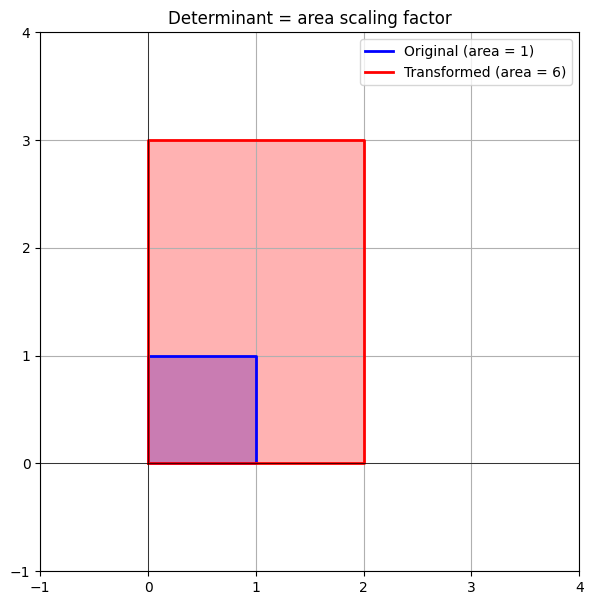

In [12]:
def plot_square(corners, color, label, ax):
    # Close the shape by appending first corner at the end
    x = np.append(corners[0], corners[0][0])
    y = np.append(corners[1], corners[1][0])
    ax.fill(x, y, color=color, alpha=0.3)
    ax.plot(x, y, color=color, linewidth=2, label=label)

fig, ax = plt.subplots(figsize=(7, 7))
plot_square(square, 'blue', 'Original (area = 1)', ax)
plot_square(transformed, 'red', 'Transformed (area = 6)', ax)

ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_aspect('equal')
ax.grid(True)
ax.legend()
ax.set_xlim(-1, 4)
ax.set_ylim(-1, 4)
ax.set_title('Determinant = area scaling factor')
plt.show()

det(F) = -1.0000


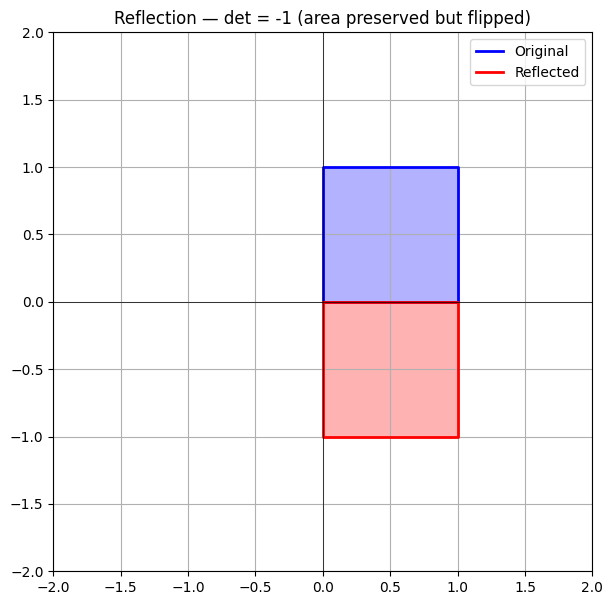

In [13]:
# Reflection across the x-axis
F = np.array([[1,  0],
              [0, -1]])

print(f"det(F) = {np.linalg.det(F):.4f}")

reflected = F @ square

fig, ax = plt.subplots(figsize=(7, 7))
plot_square(square, 'blue', 'Original', ax)
plot_square(reflected, 'red', 'Reflected', ax)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_aspect('equal')
ax.grid(True)
ax.legend()
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_title('Reflection — det = -1 (area preserved but flipped)')
plt.show()

In [ ]:
# Singular matrix — squishes everything onto a line
S = np.array([[1, 2],
              [2, 4]])

print(f"det(S) = {np.linalg.det(S):.4f}")

collapsed = S @ square
print("\nTransformed corners:\n", collapsed)

fig, ax = plt.subplots(figsize=(7, 7))
plot_square(square, 'blue', 'Original (2D square)', ax)
plot_square(collapsed, 'red', 'Collapsed (now a line)', ax)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_aspect('equal')
ax.grid(True)
ax.legend()
ax.set_xlim(-1, 4)
ax.set_ylim(-1, 7)
ax.set_title('Singular transformation — det = 0 (collapses to a line)')
plt.show()